<a href="https://colab.research.google.com/github/moulinishyam3427-eng/AIML_LAB/blob/main/WaterJugProblem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install networkx matplotlib

### Problem 2: The Water Jug Problem (Solved using BFS)

**Problem Statement:**
You are given two jugs: Jug A with a capacity of 4 litres, and Jug B with a capacity of 3 litres. Neither jug has any markings on it. Using only the following operations — (i) fill a jug completely, (ii) empty a jug completely, (iii) pour water from one jug into the other until either the first jug is empty or the second jug is full — determine the minimum sequence of steps needed to measure out exactly 2 litres of water in any one jug.

We will use a Breadth-First Search (BFS) algorithm to explore the possible states and find the shortest sequence of operations to reach the target state (2 litres in either jug).

In [ ]:
from collections import deque

def water_jug_bfs(jug_a_capacity, jug_b_capacity, target_amount):
    start_state = (0, 0)  # (water_in_jug_a, water_in_jug_b)
    queue = deque([(start_state, [start_state])])  # (current_state, path_to_current_state)
    visited = {start_state}

    while queue:
        current_state, path = queue.popleft()
        jug_a, jug_b = current_state

        # Check if the target is reached
        if jug_a == target_amount or jug_b == target_amount:
            return path

        # Generate possible next states
        next_states = []

        # 1. Fill Jug A
        next_states.append((jug_a_capacity, jug_b))
        # 2. Fill Jug B
        next_states.append((jug_a, jug_b_capacity))
        # 3. Empty Jug A
        next_states.append((0, jug_b))
        # 4. Empty Jug B
        next_states.append((jug_a, 0))

        # 5. Pour A to B
        pour_amount = min(jug_a, jug_b_capacity - jug_b)
        next_states.append((jug_a - pour_amount, jug_b + pour_amount))

        # 6. Pour B to A
        pour_amount = min(jug_b, jug_a_capacity - jug_a)
        next_states.append((jug_a + pour_amount, jug_b - pour_amount))

        for next_state in next_states:
            if next_state not in visited:
                visited.add(next_state)
                queue.append((next_state, path + [next_state]))

    return None  # No solution found

In [ ]:
# Define jug capacities and target amount
jug_a_capacity = 4
jug_b_capacity = 3
target_amount = 2

# Solve the problem using BFS
solution_path = water_jug_bfs(jug_a_capacity, jug_b_capacity, target_amount)

# Print the solution
if solution_path:
    print(f"Minimum steps to get {target_amount} litres:")
    for i, state in enumerate(solution_path):
        print(f"Step {i}: Jug A = {state[0]}L, Jug B = {state[1]}L")
else:
    print("No solution found.")

Minimum steps to get 2 litres:
Step 0: Jug A = 0L, Jug B = 0L
Step 1: Jug A = 0L, Jug B = 3L
Step 2: Jug A = 3L, Jug B = 0L
Step 3: Jug A = 3L, Jug B = 3L
Step 4: Jug A = 4L, Jug B = 2L


### Visualization of the Solution Path

We can visualize the state space as a graph where each state is a node and each operation is an edge. The BFS finds the shortest path in this graph.

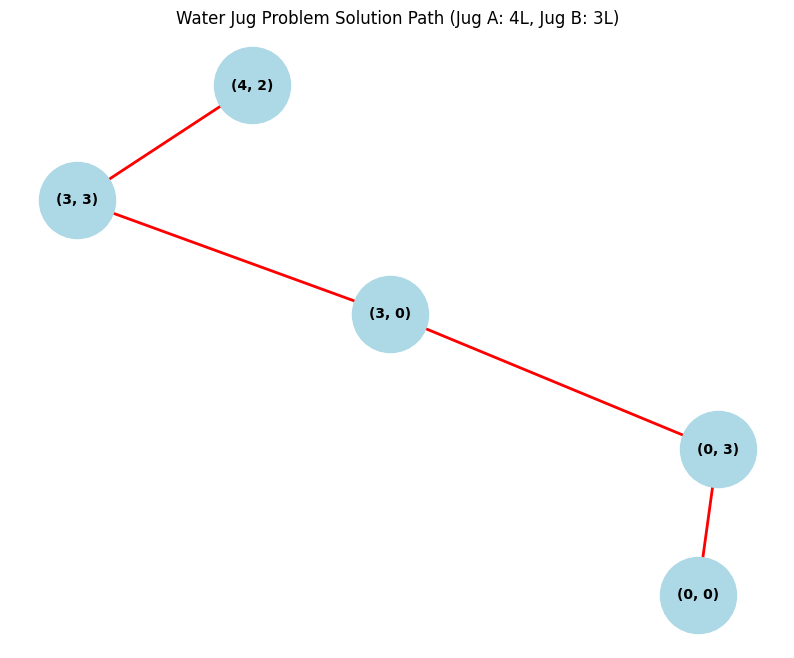

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_water_jug_solution(jug_a_capacity, jug_b_capacity, solution_path):
    G = nx.DiGraph() # Directed graph

    if not solution_path:
        print("No solution path to visualize.")
        return

    # Add nodes and edges from the solution path
    for i in range(len(solution_path) - 1):
        G.add_edge(solution_path[i], solution_path[i+1])

    # Optionally, add all possible states as nodes (this can make the graph very dense)
    # For simplicity, let's just show the solution path for now.
    # To show all possible states and connections, the BFS function would need to return the full graph.

    pos = nx.spring_layout(G)  # Layout for the graph

    plt.figure(figsize=(10, 8))
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=3000)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=20)

    # Highlight the solution path
    path_edges = [(solution_path[i], solution_path[i+1]) for i in range(len(solution_path) - 1)]
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=2, arrows=True, arrowsize=30)

    plt.title(f"Water Jug Problem Solution Path (Jug A: {jug_a_capacity}L, Jug B: {jug_b_capacity}L)")
    plt.axis('off')
    plt.show()

# Visualize the found solution
if solution_path:
    visualize_water_jug_solution(jug_a_capacity, jug_b_capacity, solution_path)